In [25]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)




In [2]:
df = pd.read_csv("/Users/mac1/Downloads/diabetes.csv", skiprows=1)

print(df.head())
print(df.tail())
print(df.shape)
print(df.info())
print(df.describe())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766    

In [3]:
x = df.drop("Outcome", axis=1)
y = df["Outcome"]


In [4]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, 
    test_size=0.2, random_state=42
)

In [14]:
# standardScalar 
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Feature scaling is important to make all features contribute at a similar level.
# fit_transform() is used only on training data because the scaler needs to learn scaling parameters (mean and standard deviation) from the training data only.
# transform() is used on test data to apply the same scaling learned from the training data without using information from the test set.

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

In [21]:
results = {}

for name, model in models.items():
    
    # Use scaled data for models that need scaling
    if name in ["Logistic Regression", "SVM", "KNN"]:
        model.fit(x_train_scaled, y_train)
        y_pred = model.predict(x_test_scaled)
        
    #For Tree-based models that don't need scaling
    else:
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)
    
    results[name] = y_pred
for key, val in results.items():
    print(key)

Logistic Regression
Decision Tree
Random Forest
SVM
KNN


In [22]:
for name, y_pred in results.items():

    print("="*50)
    print(name)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

Logistic Regression
Accuracy: 0.7532467532467533
Precision: 0.6491228070175439
Recall: 0.6727272727272727
F1 Score: 0.6607142857142857

Confusion Matrix:
[[79 20]
 [18 37]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154

Decision Tree
Accuracy: 0.7467532467532467
Precision: 0.625
Recall: 0.7272727272727273
F1 Score: 0.6722689075630253

Confusion Matrix:
[[75 24]
 [15 40]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.76      0.79        99
           1       0.62      0.73      0.67        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76   

In [23]:


comparison = []

for name, y_pred in results.items():

    comparison.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })


comparison_df = pd.DataFrame(comparison)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.753247,0.649123,0.672727,0.660714
1,Decision Tree,0.746753,0.625000,0.727273,0.672269
2,Random Forest,0.720779,0.607143,0.618182,0.612613
3,SVM,0.733766,0.645833,0.563636,0.601942
4,KNN,0.694805,0.583333,0.509091,0.543689


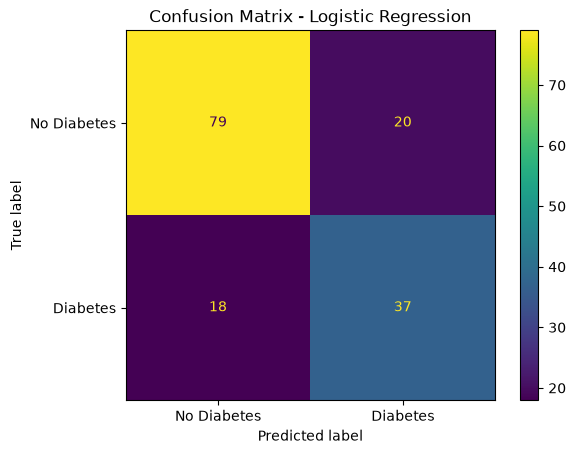

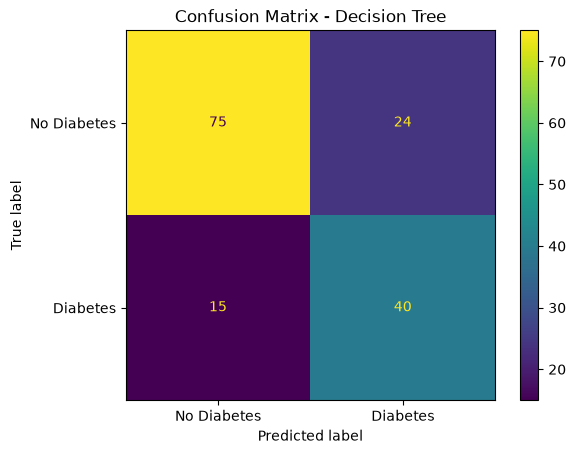

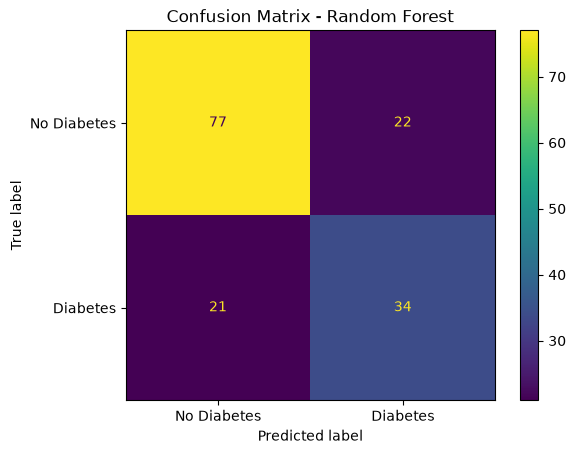

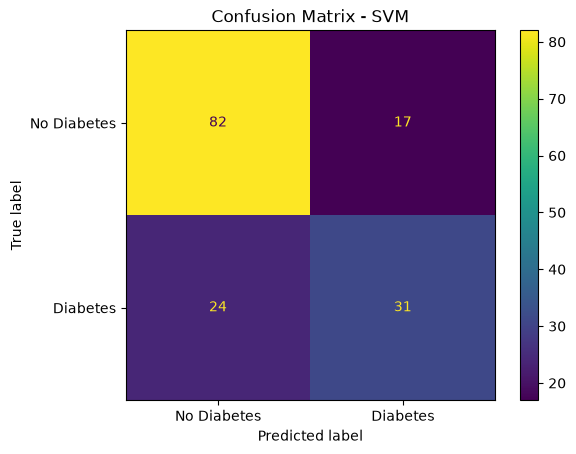

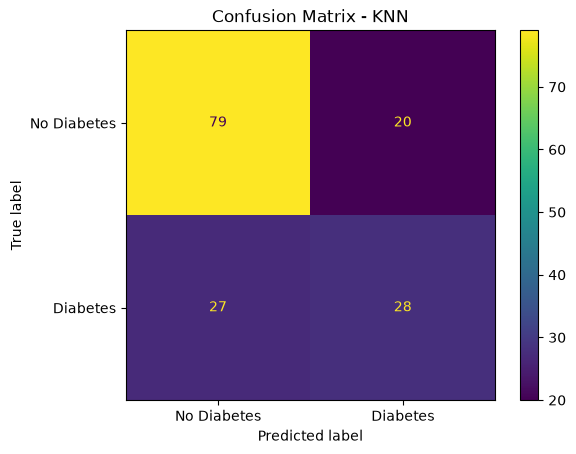

In [26]:
for name, y_pred in results.items():

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Diabetes", "Diabetes"]
    )

    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

In [28]:
for name, y_pred in results.items():

    cm = confusion_matrix(y_test, y_pred)

    TN, FP, FN, TP = cm.ravel()

    print(name)
    print("False Positives:", FP)
    print("False Negatives:", FN)
    print()

# SVM - Has fewest False Positive (Good Precision)
# Decision Tree - Has fewest False Negatives (Good Recall)

Logistic Regression
False Positives: 20
False Negatives: 18

Decision Tree
False Positives: 24
False Negatives: 15

Random Forest
False Positives: 22
False Negatives: 21

SVM
False Positives: 17
False Negatives: 24

KNN
False Positives: 20
False Negatives: 27



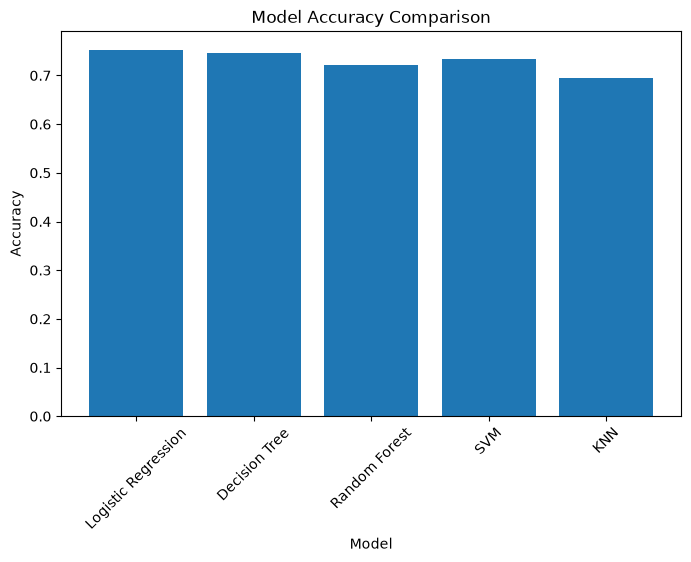

In [29]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.xticks(rotation=45)

plt.show()

# Logistic Regression Performs best

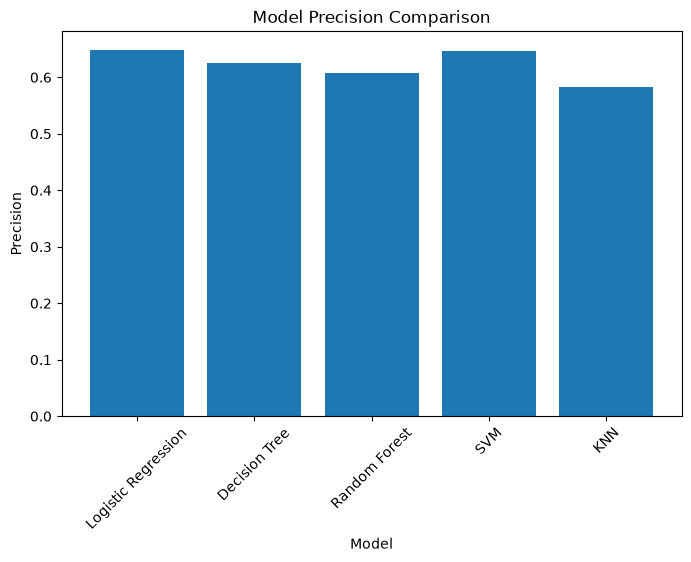

In [30]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Precision"]
)

plt.xlabel("Model")
plt.ylabel("Precision")
plt.title("Model Precision Comparison")

plt.xticks(rotation=45)

plt.show()
# Logistic Regression 

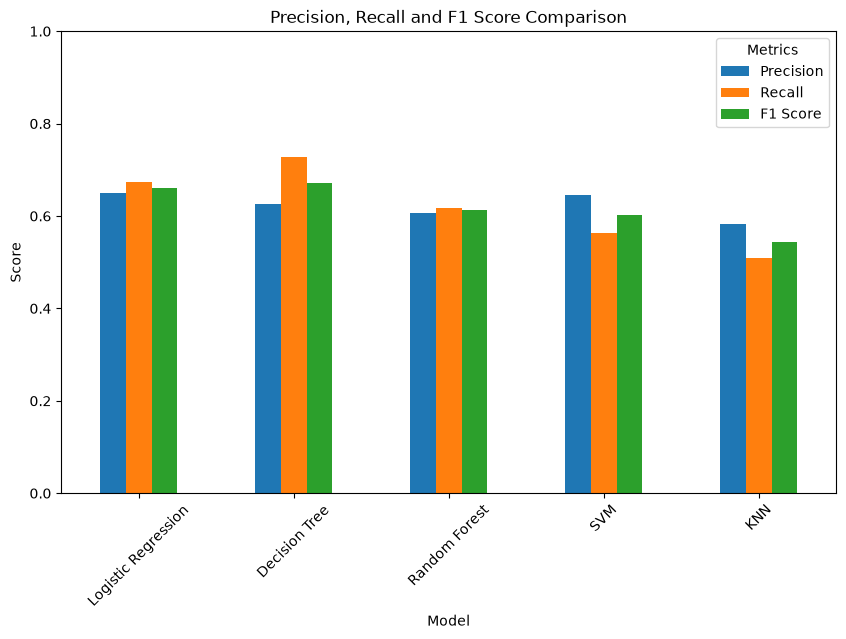

In [31]:
metrics = ["Precision", "Recall", "F1 Score"]

# Create grouped bar chart
comparison_df.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Precision, Recall and F1 Score Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)  # scores are between 0 and 1
plt.xticks(rotation=45)

plt.legend(title="Metrics")
plt.show()

# Decision tree prevides the best balance between Precision and Recall (Highest F1 Score)

## Exercise 9: Model Selection

### 1. Which model achieved the highest Accuracy?

The **Logistic Regression** model achieved the highest accuracy with an accuracy score of **0.753**. This means it correctly classified the highest percentage of samples compared to the other models.

---

### 2. Which model achieved the highest Precision?

The **Logistic Regression** model achieved the highest precision with a precision score of **0.649**. This indicates that when the model predicted a patient as diabetic, it was correct more often than the other models.

---

### 3. Which model achieved the highest Recall?

The **Decision Tree Classifier** achieved the highest recall with a recall score of **0.727**. This means it was able to identify the largest proportion of actual diabetic patients.

---

### 4. Which model achieved the highest F1 Score?

The **Decision Tree Classifier** achieved the highest F1 Score with a score of **0.672**. Since F1 Score represents the balance between precision and recall, the Decision Tree provided the best trade-off between correctly identifying diabetic patients and reducing incorrect predictions.

---

### 5. Which model would you recommend for diabetes prediction?

Based on the evaluation results, the **Decision Tree Classifier** is recommended for diabetes prediction. Although Logistic Regression achieved slightly higher accuracy, the Decision Tree achieved the highest recall and F1 Score. In a medical diagnosis problem, recall is especially important because it reduces false negatives, meaning fewer diabetic patients are incorrectly classified as non-diabetic. Therefore, the Decision Tree provides a better balance between detecting diabetic cases and maintaining reliable predictions.


In [34]:
import joblib
import json
best_model = DecisionTreeClassifier(random_state=42)
best_model.fit(x_train, y_train)
joblib.dump(
    best_model,
    "./models/best_model.pkl"
)

feature_info = {
    "features": list(x_train.columns)
}

with open("./models/feature_info.json", "w") as f:
    json.dump(feature_info, f, indent=4)
